<a href="https://colab.research.google.com/github/dwi-aprilianto/GrandBDC_Case2/blob/main/GrandBDC_Case2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#instal library yang dibutuhkan
!pip install Sastrawi
!pip install python-louvain
!pip install sentence-transformers
!pip install umap-learn
!pip install hdbscan
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.4 MB/s eta 0:00:00


In [2]:
#import library
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
from community import community_louvain

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sentence_transformers import SentenceTransformer

import umap
import hdbscan

from bertopic import BERTopic

In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/GrandBDC_Case2/case_2_dataset.xlsx'

try:
    df = pd.read_excel(file_path)
    print("✓ Berhasil memuat dataset dari Google Drive!\n")

    #5 data teratas
    print("5 DATA TERATAS")
    print(df.head())

    print("JUMLAH DATA")
    print(df.shape)

    print("NAMA KOLOM")
    print(df.columns)

    print("INFO DATASET")
    print(df.info())

    print("MISSING VALUES")
    print(df.isnull().sum())

except FileNotFoundError:
    print(f"Error: File tidak ditemukan di path: '{file_path}'")
except Exception as e:
    print(f"Terjadi error lain: {e}")

Mounted at /content/drive
✓ Berhasil memuat dataset dari Google Drive!

5 DATA TERATAS
           date lang               source              user_id  \
0  45662.580625   in              dlvr.it  1666303982007111680   
1  45752.567060   in      Twitter Web App  1356909896738820096   
2  45671.931933   in  Twitter for Android            553451866   
3  45715.643438   in  Twitter for Android  1300748401890320384   
4  45946.966262   in  Twitter for Android  1910040869513879552   

                                            hashtags  is_quote  \
0                                                 []     False   
1  ["PenuhiGiziIndonesia","Indonesiaemas","AstaCi...     False   
2                                                 []     False   
3                                                 []     False   
4                                                 []     False   

                                            mentions             tweet_id  \
0                                         

In [4]:
#cek data duplikat
print("Jumlah Duplikat:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape Setelah Hapus Duplikat:")
print(df.shape)

Jumlah Duplikat:
0

Shape Setelah Hapus Duplikat:
(15000, 32)


In [5]:
#cek data sampel
print(df[['full_text']].head())


                                           full_text
0  Surat Edaran (SE) Ditjen Pendis Kemenag Nomor ...
1  PROGRAM MAKAN BERGIZI GRATIS UNTUK ANEUK ACEH\...
2  @abu_waras @prabowo Sdh pertengahan Januari 20...
3                 @bahlilngntot @tanyakanrl Agen mbg
4  Program MBG = bukan bisnis. Ini gerakan sosial...


In [6]:
!pip install tqdm -q

In [7]:
!pip install tqdm -q

#import library
import pandas as pd
import re
import string
from tqdm import tqdm
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

tqdm.pandas()

#load dataset

file_path = '/content/drive/MyDrive/GrandBDC_Case2/case_2_dataset.xlsx'

print("Jumlah data:", df.shape)

stop_factory = StopWordRemoverFactory()

stopwords = set(stop_factory.get_stop_words())

url_pattern = re.compile(r"http\S+|www\S+")
mention_pattern = re.compile(r"@\w+")
digit_pattern = re.compile(r"\d+")
whitespace_pattern = re.compile(r"\s+")

translator = str.maketrans('', '', string.punctuation)

def clean_text(text):

    #ubah jadi string
    text = str(text)

    #lowercase
    text = text.lower()

    #hapus url
    text = url_pattern.sub("", text)

    #hapus mention
    text = mention_pattern.sub("", text)

    #hapus hastag
    text = text.replace("#", "")

    #hapus angka
    text = digit_pattern.sub("", text)

    #hapus punctuation
    text = text.translate(translator)

    #hapus extra whitespace
    text = whitespace_pattern.sub(" ", text).strip()

    #tokenization
    words = text.split()

    #hapus stopwords
    words = [word for word in words if word not in stopwords]

    #gabung lagi
    return " ".join(words)

#proses cleaning

df['clean_text'] = df['full_text'].progress_apply(clean_text)

#cek hasil

print(df[['full_text', 'clean_text']].head())

#save dataset clean

df.to_csv('/content/drive/MyDrive/GrandBDC_Case2/mbg_clean_dataset.csv', index=False)

print("\nCleaning selesai!")
print("Dataset tersimpan: mbg_clean_dataset.csv")

Jumlah data: (15000, 32)


100%|██████████| 15000/15000 [00:01<00:00, 8143.31it/s] 


                                           full_text  \
0  Surat Edaran (SE) Ditjen Pendis Kemenag Nomor ...   
1  PROGRAM MAKAN BERGIZI GRATIS UNTUK ANEUK ACEH\...   
2  @abu_waras @prabowo Sdh pertengahan Januari 20...   
3                 @bahlilngntot @tanyakanrl Agen mbg   
4  Program MBG = bukan bisnis. Ini gerakan sosial...   

                                          clean_text  
0  surat edaran se ditjen pendis kemenag nomor ta...  
1  program makan bergizi gratis aneuk aceh penuhi...  
2  sdh pertengahan januari skrg blm list yg disek...  
3                                           agen mbg  
4  program mbg bukan bisnis gerakan sosial peduli...  

Cleaning selesai!
Dataset tersimpan: mbg_clean_dataset.csv


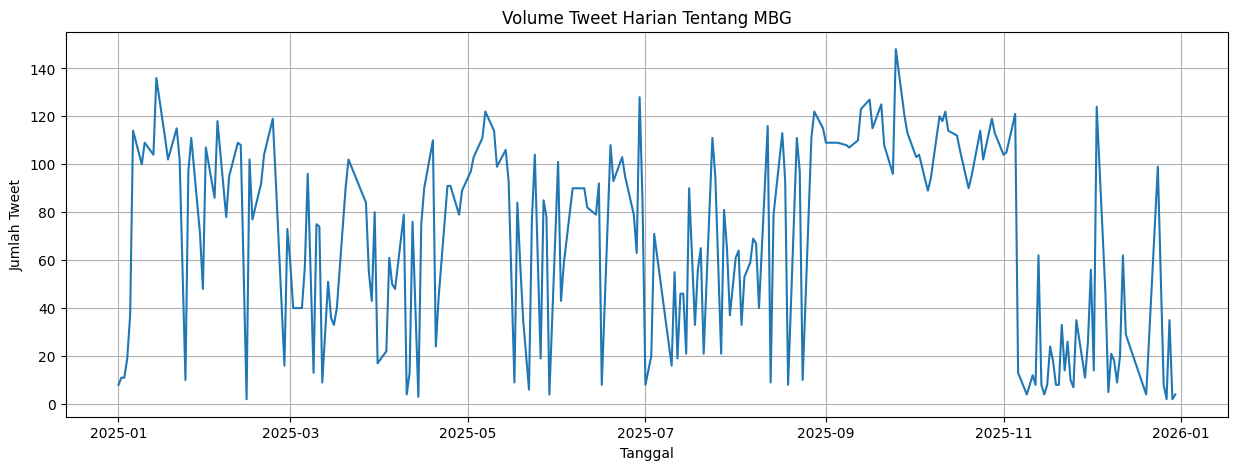

In [8]:
#temporal analisis
df['created_at'] = pd.to_datetime(df['created_at'])

df['date'] = df['created_at'].dt.date

daily_counts = df.groupby('date').size()

plt.figure(figsize=(15,5))

daily_counts.plot()

plt.title('Volume Tweet Harian Tentang MBG')

plt.xlabel('Tanggal')

plt.ylabel('Jumlah Tweet')

plt.grid(True)

plt.show()

In [9]:
#membuat network graph
G = nx.Graph()

for idx, row in df.iterrows():

    user = str(row['username'])

    text = str(row['full_text'])

    mentions = re.findall(r'@(\w+)', text)

    for mention in mentions:

        G.add_edge(user, mention)

print("Jumlah Node:")
print(G.number_of_nodes())

print("\nJumlah Edge:")
print(G.number_of_edges())

Jumlah Node:
10439

Jumlah Edge:
12272


In [10]:
#deteksi komunitas
partition = community_louvain.best_partition(G)

nx.set_node_attributes(G, partition, 'community')

print("Jumlah Community:")
print(len(set(partition.values())))

Jumlah Community:
1421


In [11]:
#centrality analysis

degree_centrality = nx.degree_centrality(G)

top_users = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

top_users_df = pd.DataFrame(
    top_users,
    columns=['username', 'centrality_score']
)

print(top_users_df)

          username  centrality_score
0          prabowo          0.066584
1         ARSIPAJA          0.038609
2             grok          0.032286
3        kompascom          0.022514
4      txtdrimedia          0.020406
5       tempodotco          0.015999
6        DS_yantie          0.011592
7     multibank_io          0.011496
8     CNNIndonesia          0.010443
9    tukang_rejceh          0.010059
10      tanyarlfes          0.009964
11        Gerindra          0.009197
12    PBB_MEGABOSS          0.009101
13      tanyakanrl          0.007952
14      zhizhie_12          0.007568
15    KangManto123          0.007568
16      _anakemaak          0.007568
17        detikcom          0.006994
18     barengwarga          0.006706
19  Mdy_Asmara1701          0.006323


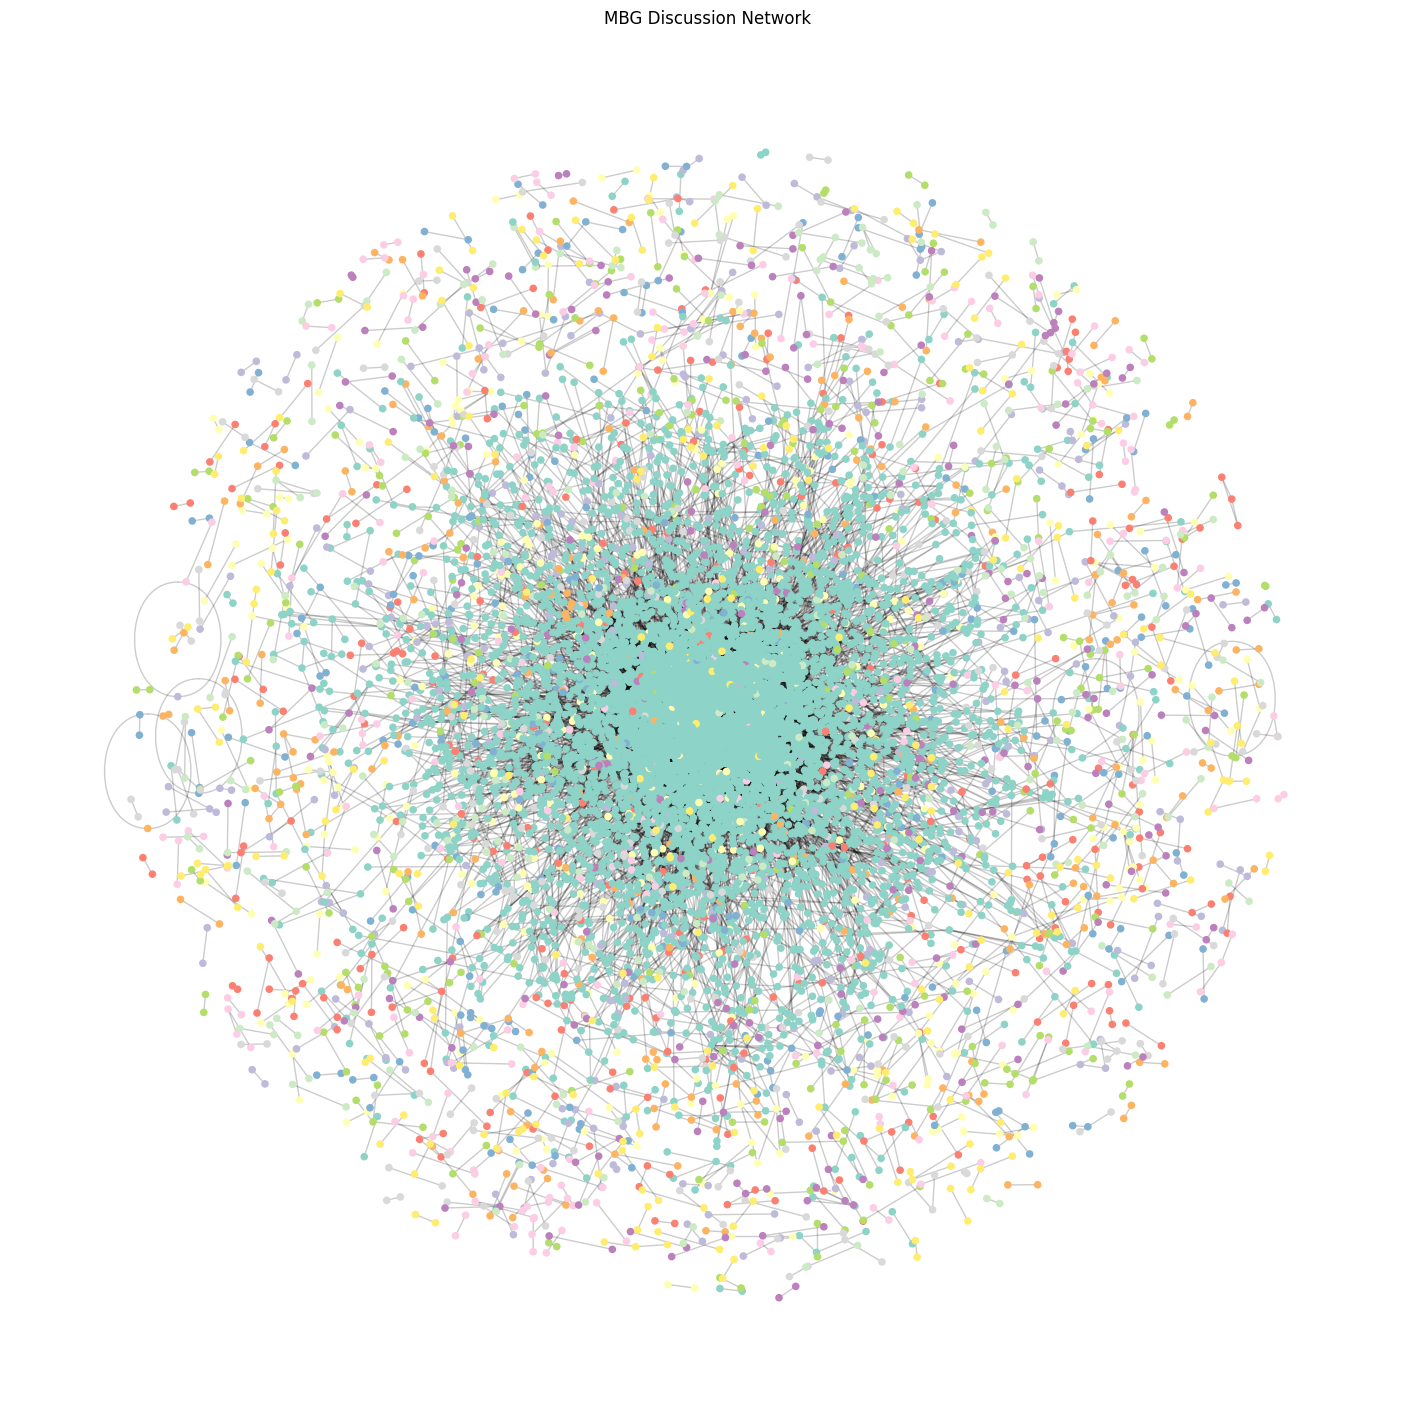

In [12]:
#network visualization

plt.figure(figsize=(18,18))

pos = nx.spring_layout(G, k=0.1)

communities = [partition.get(node) for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=20,
    node_color=communities,
    cmap=plt.cm.Set3
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title("MBG Discussion Network")

plt.axis('off')

plt.show()

In [13]:
#analisis polarisasi

modularity = community_louvain.modularity(partition, G)

print("Modularity Score:")
print(modularity)

Modularity Score:
0.8234628303435357


In [14]:
#interpretasi polarisasi

if modularity < 0.3:
    print("Tidak terlalu terpolarisasi")

elif modularity < 0.5:
    print("Polarisasi sedang")

else:
    print("Echo chamber kuat / polarisasi tinggi")

Echo chamber kuat / polarisasi tinggi


In [15]:
#sentence embedding

model = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2'
)

embeddings = model.encode(
    df['clean_text'].tolist(),
    show_progress_bar=True
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

In [16]:
#umap reducton

umap_embeddings = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

In [17]:
#hdbscan clustering

cluster = hdbscan.HDBSCAN(
    min_cluster_size=30,
    metric='euclidean'
)

labels = cluster.fit_predict(umap_embeddings)

df['narrative_cluster'] = labels

print(df['narrative_cluster'].value_counts())

narrative_cluster
 14    4049
-1     3826
 15    1470
 17    1096
 12     627
 8      599
 31     322
 21     254
 9      224
 13     217
 2      206
 19     184
 22     175
 23     174
 32     172
 29     171
 28     148
 11     134
 4       86
 33      83
 20      78
 30      77
 27      67
 16      63
 26      62
 5       53
 24      51
 25      50
 3       49
 10      46
 18      44
 7       40
 0       37
 6       36
 1       30
Name: count, dtype: int64


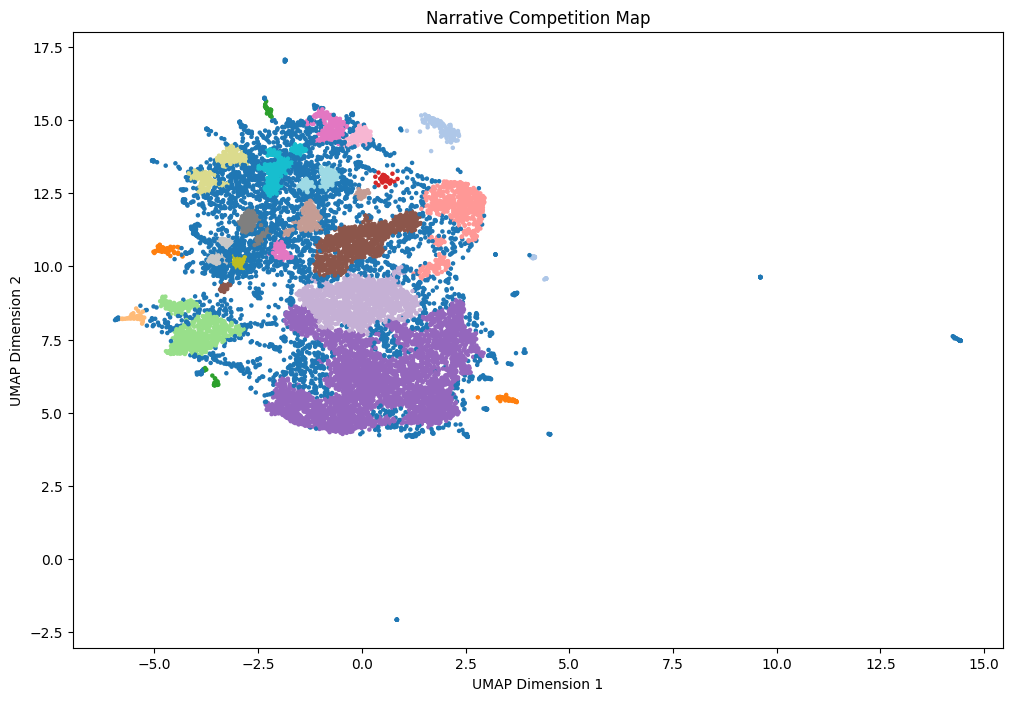

In [18]:
#narrative map
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    umap_embeddings[:,0],
    umap_embeddings[:,1],
    c=labels,
    s=5,
    cmap='tab20'
)

plt.title("Narrative Competition Map")

plt.xlabel("UMAP Dimension 1")

plt.ylabel("UMAP Dimension 2")

plt.show()

In [19]:
#BERTopic Modeling

topic_model = BERTopic(
    language="multilingual"
)

topics, probs = topic_model.fit_transform(
    df['clean_text']
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
#topic info

topic_info = topic_model.get_topic_info()

print(topic_info.head(20))

    Topic  Count                                               Name  \
0      -1   7004                                 -1_yg_mbg_ga_makan   
1       0    676  0_indonesia_indonesiaemas_dukungmbg_makanbergi...   
2       1    489                                   1_aja_aku_si_sih   
3       2    298                         2_multibank_is_mbg_bullish   
4       3    249      3_dapur_chef_berdataberdanaberdaya_sudjatmiko   
5       4    233                      4_siswa_keracunan_diduga_usai   
6       5    212                       5_sekolah_makanan_anak_makan   
7       6    204                    6_bagus_program_lanjutkan_terus   
8       7    185                    7_anakanak_tumbuh_sehat_bergizi   
9       8    176                        8_gratis_bergizi_makan_menu   
10      9    165                  9_presiden_prabowo_presidennya_lu   
11     10    153               10_korupsi_koruptor_dikorupsi_ladang   
12     11    120         11_ekonomi_mbgdorongekonomi_lokal_lapangan   
13    

In [21]:
#visualisasi topik

topic_model.visualize_topics()

In [22]:
#topic evolution

topics_over_time = topic_model.topics_over_time(
    df['clean_text'],
    df['created_at'],
    nr_bins=20
)

topic_model.visualize_topics_over_time(
    topics_over_time
)

In [23]:
#save dataset

df.to_csv(
    '/content/drive/MyDrive/GrandBDC_Case2/mbg_analysis_result.csv',
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


In [24]:
#export top influencer

top_users_df.to_csv(
    '/content/drive/MyDrive/GrandBDC_Case2/top_influencers.csv',
    index=False
)

print("Top influencers berhasil disimpan")

Top influencers berhasil disimpan


In [25]:
!pip install wordcloud

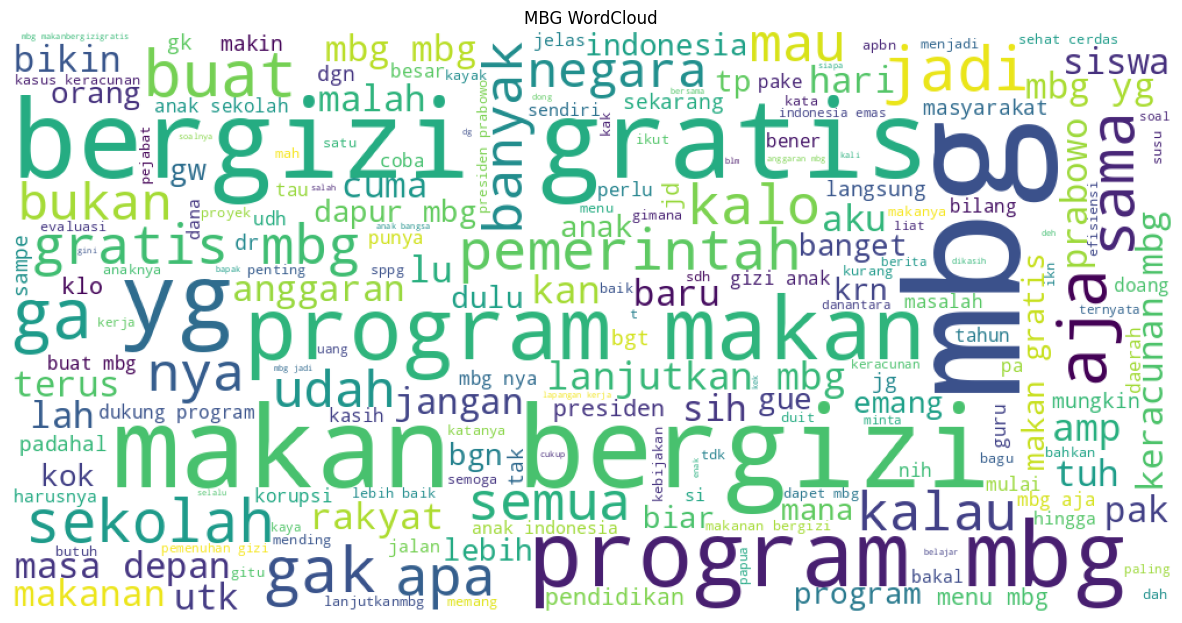

In [26]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("MBG WordCloud")

plt.show()